# Axion Data Analysis

This notebook analyzes axion-related data to identify potential candidate mass regions and visualize signal behavior using smoothing, peak detection, and scientific plotting.

## Methods
- Data parsing and cleaning
- Savitzky-Golay smoothing
- Peak detection
- Visualization

## Goal
To identify candidate regions in axion-related data for further theoretical or experimental investigation.

 FOUND 6 POTENTIAL CANDIDATES!
   Check Mass: 2.1982e-06 eV
   Check Mass: 2.2780e-06 eV
   Check Mass: 2.4953e-06 eV
   Check Mass: 2.5961e-06 eV
   Check Mass: 2.7117e-06 eV
   Check Mass: 3.2152e-06 eV


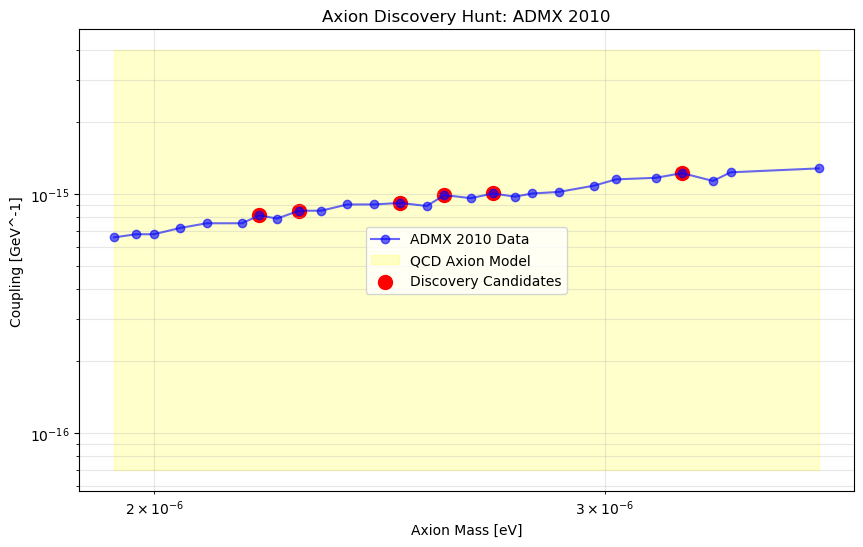

In [7]:
import io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# 1. YOUR COPIED DATA
raw_data = """# ADMX 2010
# m_a [eV]  g_ap [GeV^-1]
1.9289e-06	1e0
1.9289e-06	6.6019e-16
1.9675e-06	6.8044e-16
1.999e-06	6.8044e-16
2.047e-06	7.228e-16
2.0962e-06	7.5629e-16
2.1637e-06	7.5629e-16
2.1982e-06	8.156e-16
2.2334e-06	7.9134e-16
2.278e-06	8.5339e-16
2.3236e-06	8.5339e-16
2.3794e-06	9.0652e-16
2.4367e-06	9.0652e-16
2.4953e-06	9.2031e-16
2.5554e-06	8.9293e-16
2.5961e-06	9.9248e-16
2.6586e-06	9.6296e-16
2.7117e-06	1.0076e-15
2.766e-06	9.7761e-16
2.8102e-06	1.0076e-15
2.8778e-06	1.0229e-15
2.9704e-06	1.0866e-15
3.0297e-06	1.1542e-15
3.1397e-06	1.1718e-15
3.2152e-06	1.2261e-15
3.3057e-06	1.1369e-15
3.3584e-06	1.2354e-15
3.6354e-06	1.2829e-15
3.6354e-06	1e0"""

# 2. ANALYSIS ENGINE
def analyze_axion_string(data_string):
    # Load data from the string variable
    data = np.loadtxt(io.StringIO(data_string))
    mass = data[:, 0]
    coupling = data[:, 1]
    
    # We ignore the '1e0' points (they are just the chart borders)
    valid = coupling < 1e-10
    m, c = mass[valid], coupling[valid]

    # TRANSIENT HUNTER: Find sharp changes in the coupling
    # We look for where the experiment got 'more sensitive' suddenly
    baseline = savgol_filter(c, window_length=5, polyorder=2)
    ratio = c / baseline
    peaks, _ = find_peaks(ratio, height=1.02) # Looking for 2% deviations

    # PLOT
    plt.figure(figsize=(10, 6))
    plt.loglog(m, c, label='ADMX 2010 Data', marker='o', color='blue', alpha=0.6)
    
    # THEORY: The QCD Axion "Yellow Band" (The discovery zone)
    plt.fill_between(m, 0.7e-16, 4e-15, color='yellow', alpha=0.2, label='QCD Axion Model')

    if len(peaks) > 0:
        plt.scatter(m[peaks], c[peaks], color='red', s=100, label='Discovery Candidates')
        print(f" FOUND {len(peaks)} POTENTIAL CANDIDATES!")
        for p in peaks:
            print(f"   Check Mass: {m[p]:.4e} eV")
    
    plt.xlabel('Axion Mass [eV]')
    plt.ylabel('Coupling [GeV^-1]')
    plt.title('Axion Discovery Hunt: ADMX 2010')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

# 3. RUN IT
analyze_axion_string(raw_data)


 FOUND 51 POTENTIAL CANDIDATES!
   Check Mass: 2.6680e-06 eV
   Check Mass: 2.6744e-06 eV
   Check Mass: 2.6788e-06 eV
   Check Mass: 2.6804e-06 eV
   Check Mass: 2.6806e-06 eV
   Check Mass: 2.6813e-06 eV
   Check Mass: 2.6841e-06 eV
   Check Mass: 2.6860e-06 eV
   Check Mass: 2.6868e-06 eV
   Check Mass: 2.6873e-06 eV
   Check Mass: 2.6874e-06 eV
   Check Mass: 2.6879e-06 eV
   Check Mass: 2.6900e-06 eV
   Check Mass: 2.6953e-06 eV
   Check Mass: 2.6976e-06 eV
   Check Mass: 2.7037e-06 eV
   Check Mass: 2.7093e-06 eV
   Check Mass: 2.7107e-06 eV
   Check Mass: 2.7121e-06 eV
   Check Mass: 2.7149e-06 eV
   Check Mass: 2.7153e-06 eV
   Check Mass: 2.7200e-06 eV
   Check Mass: 2.7260e-06 eV
   Check Mass: 2.7282e-06 eV
   Check Mass: 2.7298e-06 eV
   Check Mass: 2.7298e-06 eV
   Check Mass: 2.7301e-06 eV
   Check Mass: 2.7307e-06 eV
   Check Mass: 2.7339e-06 eV
   Check Mass: 2.7395e-06 eV
   Check Mass: 2.7451e-06 eV
   Check Mass: 2.7465e-06 eV
   Check Mass: 2.7502e-06 eV
   Check Ma

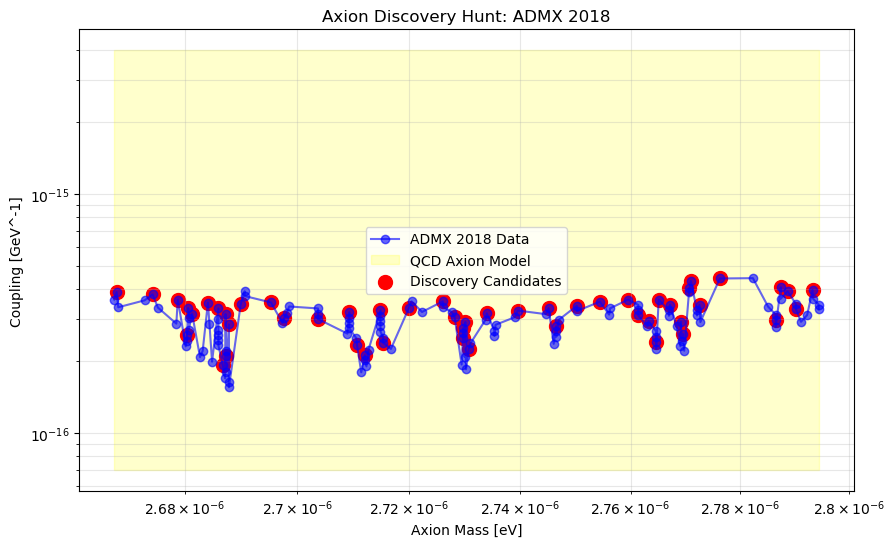

In [8]:
import io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# 1. YOUR COPIED DATA
raw_data = """# ADMX 2018 nearly DFSZ run
# m_a [eV]  g_ap [GeV^-1]
0.000002667590909090909	1e0
0.000002667590909090909	3.628501628648435e-16
0.0000026680310344827586	3.8986259755056506e-16
0.000002668310344827586	3.367383475763395e-16
0.0000026729655172413792	3.5997910476480422e-16
0.000002674362068965517	3.813571363148818e-16
0.0000026752931034482758	3.357874113865889e-16
0.0000026785517241379307	2.8762214800073255e-16
0.0000026788103448275863	3.6243062738288925e-16
0.0000026802142857142858	2.31178002324865e-16
0.0000026804137931034483	2.566779997749965e-16
0.0000026804137931034483	2.439392360472968e-16
0.000002680646551724138	3.3436603987008385e-16
0.000002680746305418719	3.0291730187473947e-16
0.000002680746305418719	2.7161388349814445e-16
0.0000026813448275862067	3.1642655700554867e-16
0.000002682741379310345	2.0824813810815062e-16
0.000002683206896551724	2.2095093897769457e-16
0.0000026841379310344826	3.5207581230432636e-16
0.00000268441724137931	2.857978464518337e-16
0.000002684869458128079	1.9940267181885678e-16
0.0000026859999999999998	3.329506849489599e-16
0.0000026859999999999998	3.0072251088396186e-16
0.0000026859999999999998	2.7161388349814445e-16
0.0000026859999999999998	2.581338614858221e-16
0.0000026859999999999998	2.453228442795581e-16
0.0000026859999999999998	2.3314762960192983e-16
0.0000026867758620689656	1.922244730520382e-16
0.0000026871637931034483	1.6997437803758487e-16
0.0000026872635467980293	3.152781367690977e-16
0.000002687396551724138	2.2157666298314684e-16
0.000002687396551724138	2.1057995598142103e-16
0.000002687396551724138	1.8075739334982277e-16
0.000002687862068965517	2.857978464518337e-16
0.000002687862068965517	1.6326086608691467e-16
0.000002687862068965517	1.5581790399343106e-16
0.0000026899568965517242	3.4737807304666585e-16
0.000002690655172413793	3.928507802891461e-16
0.000002690655172413793	3.752061286598932e-16
0.000002695310344827586	3.528233461047414e-16
0.000002697358620689655	2.8994965628127017e-16
0.0000026976379310344826	3.0242819033277624e-16
0.000002698103448275862	3.1732266404902794e-16
0.0000026985689655172414	3.392873639774295e-16
0.000002703689655172414	3.329506849489599e-16
0.000002703689655172414	3.1642655700554867e-16
0.000002703689655172414	3.0072251088396186e-16
0.0000027089433497536946	2.6128143130634593e-16
0.0000027092758620689654	3.2093254157675635e-16
0.0000027092758620689654	3.0500486634451765e-16
0.0000027092758620689654	2.898676713703957e-16
0.0000027092758620689654	2.7548172562856016e-16
0.000002710539408866995	2.498235317806617e-16
0.000002710672413793103	2.3314762960192983e-16
0.0000027114172413793104	1.799922562374934e-16
0.0000027120689655172413	2.1237408873251844e-16
0.0000027120689655172413	2.0183409956079032e-16
0.000002712348275862069	1.905197295453584e-16
0.0000027127206896551722	2.2384397781979226e-16
0.0000027148620689655173	3.2642450265768853e-16
0.0000027148620689655173	3.102242649359764e-16
0.0000027148620689655173	2.948280345730967e-16
0.0000027148620689655173	2.8019590920192717e-16
0.0000027148620689655173	2.6628996678410985e-16
0.0000027153275862068962	2.5164684203177894e-16
0.0000027153275862068962	2.395639125646289e-16
0.0000027167241379310344	2.253683956742838e-16
0.0000027199827586206894	3.3560941004132167e-16
0.0000027204482758620688	3.563328777228033e-16
0.000002722310344827586	3.2184140938390186e-16
0.0000027260344827586207	3.563328777228033e-16
0.0000027260344827586207	3.386483066193135e-16
0.0000027276970443349753	3.204790706046109e-16
0.0000027281758620689653	3.0586862762806248e-16
0.0000027294261083743842	1.9392096607716632e-16
0.000002729758620689655	2.7587152632815985e-16
0.000002729758620689655	2.621802002457729e-16
0.000002729758620689655	2.493445874704188e-16
0.0000027299702194357364	2.0864000209089634e-16
0.0000027300911330049258	2.921012227276251e-16
0.0000027302241379310344	1.85259767013118e-16
0.000002730689655172414	2.247319639610108e-16
0.0000027310221674876845	2.3800115819815325e-16
0.0000027337620689655172	2.991956259812074e-16
0.0000027339482758620687	3.1777166877398125e-16
0.000002735344827586207	2.689387514190247e-16
0.000002735344827586207	2.555914944879555e-16
0.0000027355443349753694	2.844156728086468e-16
0.0000027390689655172412	3.0630142513854336e-16
0.0000027395344827586206	3.2630913375990437e-16
0.000002744655172413793	3.1508713902875256e-16
0.0000027451206896551725	3.340116380806745e-16
0.000002746051724137931	2.368023004189189e-16
0.0000027465172413793103	2.8059238036959786e-16
0.0000027465172413793103	2.666667613432117e-16
0.0000027465172413793103	2.5343226181555494e-16
0.0000027469827586206897	2.9849839703943373e-16
0.0000027502413793103446	3.4153357656429816e-16
0.0000027502413793103446	3.2458348524076045e-16
0.0000027544310344827583	3.553266073307795e-16
0.000002756106896551724	3.1375339074205315e-16
0.000002756293103448276	3.3330396101804846e-16
0.000002759551724137931	3.6243062738288925e-16
0.000002761413793103448	3.444434288931077e-16
0.000002761413793103448	3.2734892347357543e-16
0.000002761413793103448	3.111028073424611e-16
0.0000027630763546798026	2.7979999823972703e-16
0.0000027632758620689656	2.9566297548607283e-16
0.0000027646724137931034	2.6704408905848825e-16
0.0000027646724137931034	2.5379086299946814e-16
0.0000027646724137931034	2.4119538600949134e-16
0.0000027646724137931034	2.253683956742838e-16
0.0000027651379310344828	3.6243062738288925e-16
0.000002767	3.2642450265768853e-16
0.000002767	3.102242649359764e-16
0.0000027671995073891625	3.4527935966954585e-16
0.0000027683965517241377	2.8027515859367333e-16
0.000002769094827586207	2.31178002324865e-16
0.0000027691945812807883	2.931652196121226e-16
0.0000027693275862068965	2.439392360472968e-16
0.000002769513793103448	2.6077525307511444e-16
0.000002769793103448276	2.2157666298314684e-16
0.0000027707241379310343	4.052634576190777e-16
0.0000027707241379310343	3.884319600705763e-16
0.000002771003448275862	4.3347873244762607e-16
0.0000027721206896551724	3.2734892347357543e-16
0.0000027721206896551724	3.111028073424611e-16
0.000002772586206896552	3.446870327611195e-16
0.000002772741379310345	2.919242657268488e-16
0.000002776310344827586	4.442759850103119e-16
0.000002782362068965517	4.456916781413068e-16
0.000002785155172413793	3.3880795802494123e-16
0.0000027865517241379308	3.1375339074205315e-16
0.0000027865517241379308	2.9818201213955666e-16
0.0000027865517241379308	2.7822194063123936e-16
0.0000027874827586206896	4.081387784020947e-16
0.0000027874827586206896	3.6551852174376317e-16
0.000002788746305418719	3.926127884889631e-16
0.0000027902758620689655	3.4737807304666585e-16
0.0000027902758620689655	3.3013792312885236e-16
0.000002791206896551724	2.9285448746222036e-16
0.0000027923374384236452	3.122360186815983e-16
0.0000027933275862068966	3.971326461158082e-16
0.0000027934014778325122	3.6618362860389853e-16
0.0000027944655172413792	3.45418878569746e-16
0.0000027944655172413792	3.296714451450125e-16
0.0000027944655172413792	1e0"""

# 2. ANALYSIS ENGINE
def analyze_axion_string(data_string):
    # Load data from the string variable
    data = np.loadtxt(io.StringIO(data_string))
    mass = data[:, 0]
    coupling = data[:, 1]
    
    # We ignore the '1e0' points (they are just the chart borders)
    valid = coupling < 1e-10
    m, c = mass[valid], coupling[valid]

    # TRANSIENT HUNTER: Find sharp changes in the coupling
    # We look for where the experiment got 'more sensitive' suddenly
    baseline = savgol_filter(c, window_length=5, polyorder=2)
    ratio = c / baseline
    peaks, _ = find_peaks(ratio, height=1.02) # Looking for 2% deviations

    # PLOT
    plt.figure(figsize=(10, 6))
    plt.loglog(m, c, label='ADMX 2018 Data', marker='o', color='blue', alpha=0.6)
    
    # THEORY: The QCD Axion "Yellow Band" (The discovery zone)
    plt.fill_between(m, 0.7e-16, 4e-15, color='yellow', alpha=0.2, label='QCD Axion Model')

    if len(peaks) > 0:
        plt.scatter(m[peaks], c[peaks], color='red', s=100, label='Discovery Candidates')
        print(f" FOUND {len(peaks)} POTENTIAL CANDIDATES!")
        for p in peaks:
            print(f"   Check Mass: {m[p]:.4e} eV")
    
    plt.xlabel('Axion Mass [eV]')
    plt.ylabel('Coupling [GeV^-1]')
    plt.title('Axion Discovery Hunt: ADMX 2018')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

# 3. RUN IT
analyze_axion_string(raw_data)


 FOUND 55 POTENTIAL CANDIDATES!
   Check Mass: 2.8070e-06 eV
   Check Mass: 2.8126e-06 eV
   Check Mass: 2.8159e-06 eV
   Check Mass: 2.8168e-06 eV
   Check Mass: 2.8275e-06 eV
   Check Mass: 2.8308e-06 eV
   Check Mass: 2.8363e-06 eV
   Check Mass: 2.8376e-06 eV
   Check Mass: 2.8416e-06 eV
   Check Mass: 2.8429e-06 eV
   Check Mass: 2.8447e-06 eV
   Check Mass: 2.8471e-06 eV
   Check Mass: 2.8527e-06 eV
   Check Mass: 2.8638e-06 eV
   Check Mass: 2.8694e-06 eV
   Check Mass: 2.8750e-06 eV
   Check Mass: 2.8806e-06 eV
   Check Mass: 2.8858e-06 eV
   Check Mass: 2.9094e-06 eV
   Check Mass: 2.9374e-06 eV
   Check Mass: 2.9430e-06 eV
   Check Mass: 2.9495e-06 eV
   Check Mass: 2.9537e-06 eV
   Check Mass: 2.9616e-06 eV
   Check Mass: 2.9673e-06 eV
   Check Mass: 2.9718e-06 eV
   Check Mass: 2.9731e-06 eV
   Check Mass: 2.9828e-06 eV
   Check Mass: 2.9886e-06 eV
   Check Mass: 2.9942e-06 eV
   Check Mass: 2.9998e-06 eV
   Check Mass: 3.0053e-06 eV
   Check Mass: 3.0113e-06 eV
   Check Ma

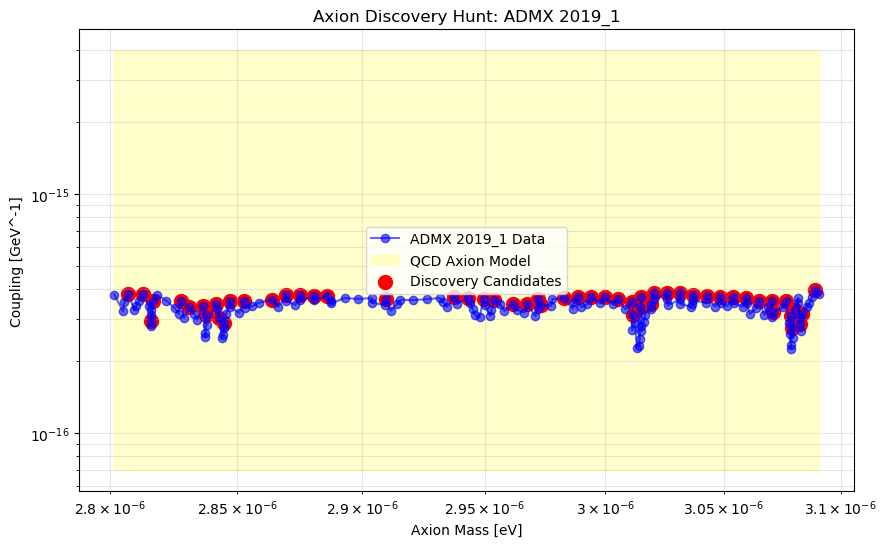

In [9]:
import io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# 1. YOUR COPIED DATA
raw_data = """# ADMX 2019_1 DFSZ Run
# m_a [eV]  g_ap [GeV^-1]
0.000002801448275862069	1e0
0.000002801448275862069	3.8072855242911103e-16
0.000002804960815047022	3.2333420286324195e-16
0.000002805384012539185	3.5277799587844587e-16
0.0000028070344827586204	3.813571363148818e-16
0.000002809362068965517	3.2734892347357543e-16
0.0000028101068965517243	3.4211357376281776e-16
0.0000028112241379310345	3.589879167262412e-16
0.0000028126206896551723	3.810337350917889e-16
0.0000028151344827586204	3.4240394161742497e-16
0.0000028158793103448272	3.2734892347357543e-16
0.0000028158793103448272	3.111028073424611e-16
0.0000028158793103448272	2.9566297548607283e-16
0.0000028158793103448272	2.8218388296540784e-16
0.000002816810344827586	3.589879167262412e-16
0.0000028182068965517242	3.8038775517212655e-16
0.0000028219310344827585	3.584806743045595e-16
0.0000028251896551724135	3.3436603987008385e-16
0.000002826785714285714	3.152781367690977e-16
0.0000028275172413793105	3.5734199783134267e-16
0.0000028289137931034482	3.040575459764756e-16
0.0000028307758620689654	3.364210699988274e-16
0.0000028329039408866994	3.1681029259796613e-16
0.0000028341275862068967	2.989418999533654e-16
0.0000028362689655172413	3.4211357376281776e-16
0.0000028372931034482757	2.632947137560725e-16
0.0000028372931034482757	2.5271657881970465e-16
0.0000028376422413793102	3.1176334650977954e-16
0.000002837758620689655	2.8258316707307427e-16
0.0000028415758620689654	3.481156325212172e-16
0.0000028419482758620688	3.310728601993517e-16
0.0000028428793103448276	3.045739008445069e-16
0.000002843810344827586	2.50581633386806e-16
0.0000028444310344827588	2.588648860042021e-16
0.0000028447413793103447	2.906885647380387e-16
0.0000028447413793103447	2.7665278318655216e-16
0.0000028454655172413793	3.1508713902875256e-16
0.0000028470689655172413	3.563328777228033e-16
0.0000028470689655172413	3.386483066193135e-16
0.0000028506379310344826	3.1897212321700026e-16
0.0000028526551724137928	3.563328777228033e-16
0.000002853120689655172	3.357874113865889e-16
0.000002855913793103448	3.400878818145933e-16
0.000002858520689655172	3.5182698649552185e-16
0.0000028638275862068966	3.6268695250135683e-16
0.0000028662881773399014	3.3885358653500713e-16
0.000002869413793103448	3.7813543760290444e-16
0.0000028694802955665024	3.5784762905037764e-16
0.000002873137931034483	3.444434288931077e-16
0.000002875	3.7813543760290444e-16
0.000002875	3.59622979190104e-16
0.0000028805862068965515	3.745435477284417e-16
0.0000028805862068965515	3.5975012643311385e-16
0.0000028858399014778326	3.749409557477848e-16
0.0000028874525862068963	3.5917831762144874e-16
0.000002887568965517241	3.4934837995326334e-16
0.000002892948275862069	3.6845901955600695e-16
0.0000028982758620689656	3.6461517815348003e-16
0.000002903862068965517	3.68111854506411e-16
0.000002903862068965517	3.5157833654169364e-16
0.0000029092155172413793	3.4426083898165817e-16
0.000002909448275862069	3.6551852174376317e-16
0.0000029115689655172413	3.2565614644496333e-16
0.000002914103448275862	3.481156325212172e-16
0.0000029155	3.618545580193836e-16
0.0000029206206896551724	3.606414167311829e-16
0.000002926206896551724	3.6435749028218854e-16
0.0000029314439655172412	3.6785169539656456e-16
0.000002933003448275862	3.536224649965858e-16
0.0000029345862068965517	3.381698036415114e-16
0.0000029373793103448277	3.717734608219697e-16
0.0000029386827586206895	3.4885475799552704e-16
0.000002942965517241379	3.68111854506411e-16
0.000002943896551724138	3.497808720916137e-16
0.000002944943965517241	3.3154132115526487e-16
0.0000029460379310344826	3.1216034300477574e-16
0.000002947853448275862	3.0554443086155564e-16
0.0000029494827586206895	3.6551852174376317e-16
0.000002949948275862069	3.4389594948089863e-16
0.0000029521827586206894	3.105753837891479e-16
0.000002952741379310345	3.2704049268691743e-16
0.000002953672413793103	3.6140713717949095e-16
0.0000029562793103448276	3.4737807304666585e-16
0.0000029580736677115987	3.2508454868495804e-16
0.0000029615862068965516	3.4737807304666585e-16
0.000002963115763546798	3.289397396535796e-16
0.0000029662413793103448	3.1980006526030066e-16
0.0000029673275862068965	3.4737807304666585e-16
0.000002970896551724138	3.0912957497059046e-16
0.0000029718275862068962	3.6551852174376317e-16
0.0000029718275862068962	3.308388780019588e-16
0.000002973091133004926	3.4569808552140134e-16
0.0000029774802955665025	3.4236244541151083e-16
0.0000029778793103448276	3.6455073910504015e-16
0.0000029828448275862067	3.6689935073687776e-16
0.000002986351724137931	3.3154132115526487e-16
0.0000029867241379310344	3.5332258352904945e-16
0.0000029885862068965516	3.717734608219697e-16
0.0000029899827586206893	3.3721482507468603e-16
0.0000029925219435736677	3.471102572174299e-16
0.0000029941724137931035	3.717734608219697e-16
0.000002997741379310345	3.498427003754238e-16
0.000002999758620689655	3.717734608219697e-16
0.0000030030172413793103	3.468259291318957e-16
0.000003005344827586207	3.639712999065425e-16
0.000003008349529780564	3.3052007784268244e-16
0.0000030112635467980295	3.546095830307546e-16
0.000003011280172413793	2.7032078195155075e-16
0.0000030113965517241377	3.1242528814593237e-16
0.0000030123275862068965	2.8961161790728464e-16
0.000003013258620689655	2.2825471626921685e-16
0.0000030141896551724137	2.324892296301443e-16
0.0000030143060344827586	3.3650036135643334e-16
0.0000030143758620689656	2.4825401909401446e-16
0.0000030150275862068965	3.7335384921311627e-16
0.0000030151206896551725	2.8098941253542e-16
0.0000030151206896551725	2.6704408905848825e-16
0.000003016051724137931	2.9161484889077956e-16
0.000003016583743842364	3.118578236658357e-16
0.0000030193103448275862	3.4737807304666585e-16
0.0000030193103448275862	3.3060506116897744e-16
0.0000030202413793103446	3.846062837702437e-16
0.0000030205738916256158	3.6331021134454655e-16
0.0000030258275862068965	3.846062837702437e-16
0.0000030258275862068965	3.6551852174376317e-16
0.0000030262	3.428399555562578e-16
0.000003031347290640394	3.6331021134454655e-16
0.000003031413793103448	3.846062837702437e-16
0.000003031506896551724	3.482633322298005e-16
0.000003036068965517241	3.3721482507468603e-16
0.0000030365344827586205	3.4688723509139783e-16
0.000003037	3.797428704049864e-16
0.000003037	3.6089647644988266e-16
0.000003042543887147335	3.503377202503191e-16
0.000003042586206896552	3.749409557477848e-16
0.000003046310344827586	3.391274866685079e-16
0.0000030481724137931033	3.728263080291508e-16
0.000003048770935960591	3.5097520373539953e-16
0.0000030514310344827586	3.404487307795099e-16
0.000003053758620689655	3.717734608219697e-16
0.0000030541077586206893	3.495954527945547e-16
0.0000030581810344827586	3.3882791974203036e-16
0.0000030593448275862067	3.665536552197785e-16
0.000003059810344827586	3.4934837995326334e-16
0.000003061051724137931	3.1597945289540584e-16
0.0000030635344827586204	3.335789904238373e-16
0.0000030649310344827586	3.58353975726681e-16
0.000003067165517241379	3.132214735612909e-16
0.000003068655172413793	3.386483066193135e-16
0.00000307051724137931	3.565848902741589e-16
0.00000307051724137931	3.071688582234648e-16
0.0000030709827586206895	3.2229680803603425e-16
0.000003075172413793103	3.3602489338038484e-16
0.0000030765689655172414	3.5671096337938704e-16
0.0000030776330049261084	2.8840755195164226e-16
0.0000030782758620689656	2.6014916393209385e-16
0.0000030784310344827586	3.0847461602711447e-16
0.0000030784310344827586	2.351340380241362e-16
0.0000030784310344827586	2.25687287092948e-16
0.000003079051724137931	2.7626187858734263e-16
0.0000030793620689655173	2.50581633386806e-16
0.0000030802931034482757	3.2769625581476834e-16
0.0000030816896551724135	3.686327248403345e-16
0.0000030816896551724135	3.503377202503191e-16
0.0000030826206896551723	3.023213025020728e-16
0.0000030826206896551723	2.857978464518337e-16
0.0000030827758620689653	2.6817927869074356e-16
0.000003083551724137931	3.1642655700554867e-16
0.0000030854137931034482	3.391274866685079e-16
0.0000030865	3.498427003754238e-16
0.000003087648275862069	3.711431801716317e-16
0.0000030891379310344826	3.992910486436584e-16
0.0000030905344827586203	3.813571363148818e-16
0.0000030905344827586203	1e0
"""

# 2. ANALYSIS ENGINE
def analyze_axion_string(data_string):
    # Load data from the string variable
    data = np.loadtxt(io.StringIO(data_string))
    mass = data[:, 0]
    coupling = data[:, 1]
    
    # We ignore the '1e0' points (they are just the chart borders)
    valid = coupling < 1e-10
    m, c = mass[valid], coupling[valid]

    # TRANSIENT HUNTER: Find sharp changes in the coupling
    # We look for where the experiment got 'more sensitive' suddenly
    baseline = savgol_filter(c, window_length=5, polyorder=2)
    ratio = c / baseline
    peaks, _ = find_peaks(ratio, height=1.02) # Looking for 2% deviations

    # PLOT
    plt.figure(figsize=(10, 6))
    plt.loglog(m, c, label='ADMX 2019_1 Data', marker='o', color='blue', alpha=0.6)
    
    # THEORY: The QCD Axion "Yellow Band" (The discovery zone)
    plt.fill_between(m, 0.7e-16, 4e-15, color='yellow', alpha=0.2, label='QCD Axion Model')

    if len(peaks) > 0:
        plt.scatter(m[peaks], c[peaks], color='red', s=100, label='Discovery Candidates')
        print(f" FOUND {len(peaks)} POTENTIAL CANDIDATES!")
        for p in peaks:
            print(f"   Check Mass: {m[p]:.4e} eV")
    
    plt.xlabel('Axion Mass [eV]')
    plt.ylabel('Coupling [GeV^-1]')
    plt.title('Axion Discovery Hunt: ADMX 2019_1')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

# 3. RUN IT
analyze_axion_string(raw_data)


 FOUND 24 POTENTIAL CANDIDATES!
   Check Mass: 3.1455e-06 eV
   Check Mass: 3.1492e-06 eV
   Check Mass: 3.1594e-06 eV
   Check Mass: 3.1622e-06 eV
   Check Mass: 3.1658e-06 eV
   Check Mass: 3.1710e-06 eV
   Check Mass: 3.1767e-06 eV
   Check Mass: 3.1822e-06 eV
   Check Mass: 3.1871e-06 eV
   Check Mass: 3.1878e-06 eV
   Check Mass: 3.2063e-06 eV
   Check Mass: 3.2240e-06 eV
   Check Mass: 3.2265e-06 eV
   Check Mass: 3.2301e-06 eV
   Check Mass: 3.2381e-06 eV
   Check Mass: 3.2493e-06 eV
   Check Mass: 3.2551e-06 eV
   Check Mass: 3.2608e-06 eV
   Check Mass: 3.2662e-06 eV
   Check Mass: 3.2688e-06 eV
   Check Mass: 3.2842e-06 eV
   Check Mass: 3.2897e-06 eV
   Check Mass: 3.3000e-06 eV
   Check Mass: 3.3070e-06 eV


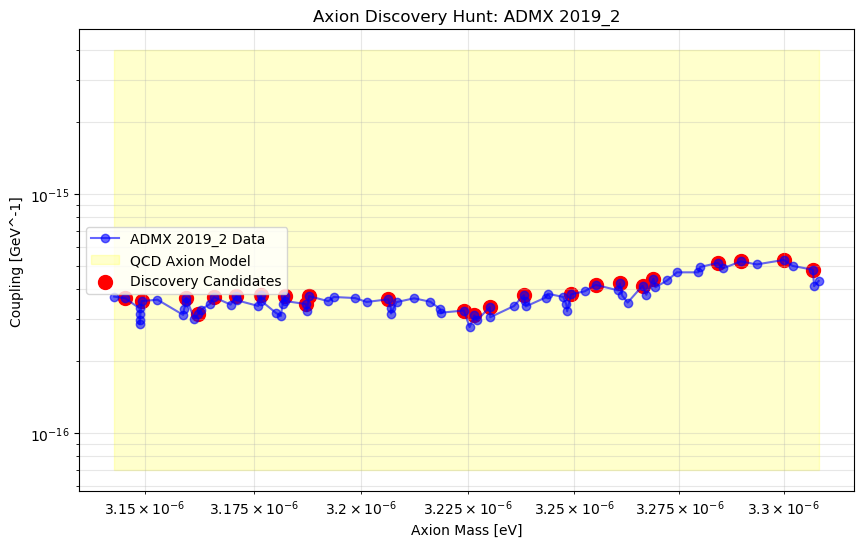

In [10]:
import io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# 1. YOUR COPIED DATA
raw_data = """# ADMX 2019 DFSZ run
# m_a [eV]  g_ap [GeV^-1]
0.0000031428965517241377	1e0
0.0000031428965517241377	3.732951966831216e-16
0.000003145465517241379	3.672670094566324e-16
0.0000031487241379310343	3.329506849489599e-16
0.0000031487241379310343	3.1642655700554867e-16
0.0000031487241379310343	2.965002809175006e-16
0.0000031487241379310343	2.8701275726808332e-16
0.0000031491896551724137	3.571736129074003e-16
0.0000031528275862068963	3.6220293491788783e-16
0.0000031587327586206896	3.1292266653428247e-16
0.0000031589655172413793	3.3154132115526487e-16
0.0000031594310344827583	3.54323178607784e-16
0.0000031594310344827583	3.686327248403345e-16
0.000003161293103448276	3.0157414471231587e-16
0.0000031622241379310342	3.1642655700554867e-16
0.0000031628448275862066	3.29205626284812e-16
0.0000031649241379310342	3.4782042099738536e-16
0.0000031658152709359603	3.7132315124375583e-16
0.0000031696724137931033	3.45418878569746e-16
0.000003171002463054187	3.7585090106235614e-16
0.000003171162068965517	3.5997910476480422e-16
0.0000031760566502463054	3.4091324210094294e-16
0.000003176655172413793	3.7813543760290444e-16
0.000003176655172413793	3.593688195019504e-16
0.0000031800689655172413	3.1980006526030066e-16
0.000003181310344827586	3.0978592453486754e-16
0.0000031816827586206895	3.4649506412575615e-16
0.0000031822413793103445	3.75471489112659e-16
0.0000031822413793103445	3.5784762905037764e-16
0.0000031871081504702194	3.471102572174299e-16
0.000003187362068965517	3.241248555615408e-16
0.0000031878275862068964	3.749409557477848e-16
0.0000031923275862068965	3.5683708105865146e-16
0.0000031935689655172413	3.717734608219697e-16
0.000003198534482758621	3.68046797484527e-16
0.0000032012344827586204	3.5437328267826884e-16
0.000003206293103448276	3.636283632224689e-16
0.0000032069137931034482	3.329506849489599e-16
0.0000032069137931034482	3.1687429375836456e-16
0.00000320821724137931	3.539226009876037e-16
0.0000032123137931034482	3.6707232073532037e-16
0.0000032161310344827585	3.5512569450977817e-16
0.000003218365517241379	3.3154132115526487e-16
0.000003218644827586207	3.196644369237144e-16
0.0000032239827586206895	3.2627068652248187e-16
0.000003225348275862069	2.7814327179852365e-16
0.000003226465517241379	3.1143290180337866e-16
0.0000032270862068965515	2.9712981573378835e-16
0.000003230096551724138	3.3721482507468603e-16
0.000003230189655172414	3.0586862762806248e-16
0.0000032357758620689653	3.4080996262186044e-16
0.000003238103448275862	3.786704910906999e-16
0.0000032383029556650244	3.5871609051982685e-16
0.0000032385689655172413	3.393673308942115e-16
0.0000032432241379310344	3.6967667761190956e-16
0.0000032438448275862068	3.835201703629796e-16
0.000003247413793103448	3.717734608219697e-16
0.000003248133228840125	3.4697642674135535e-16
0.000003248344827586207	3.2389578379199656e-16
0.0000032492758620689653	3.813571363148818e-16
0.0000032525344827586206	3.928507802891461e-16
0.0000032550736677115986	4.180145945813664e-16
0.0000032604482758620687	3.9619785312865755e-16
0.000003260820689655172	4.235183878030318e-16
0.0000032613793103448275	3.773342745736899e-16
0.0000032626827586206893	3.5227499965052514e-16
0.000003266246081504702	4.1480301227392864e-16
0.0000032671206896551724	3.797428704049864e-16
0.0000032688275862068965	4.43334688695387e-16
0.0000032692931034482755	4.081387784020947e-16
0.0000032720862068965515	4.35875760715659e-16
0.000003274413793103448	4.714594260342789e-16
0.0000032795344827586205	4.714594260342789e-16
0.00000328	4.964303804717844e-16
0.0000032841896551724137	5.161139921293831e-16
0.000003285469827586207	4.900663064055565e-16
0.0000032896827586206896	5.239819429873721e-16
0.0000032935	5.088676042308745e-16
0.00000330001724137931	5.311993973993045e-16
0.0000033021332288401253	5.014650511368152e-16
0.000003307	4.836128329428769e-16
0.000003307310344827586	4.127817843114382e-16
0.000003308413793103448	4.340648165032745e-16
0.000003308413793103448	1e0"""

# 2. ANALYSIS ENGINE
def analyze_axion_string(data_string):
    # Load data from the string variable
    data = np.loadtxt(io.StringIO(data_string))
    mass = data[:, 0]
    coupling = data[:, 1]
    
    # We ignore the '1e0' points (they are just the chart borders)
    valid = coupling < 1e-10
    m, c = mass[valid], coupling[valid]

    # TRANSIENT HUNTER: Find sharp changes in the coupling
    # We look for where the experiment got 'more sensitive' suddenly
    baseline = savgol_filter(c, window_length=5, polyorder=2)
    ratio = c / baseline
    peaks, _ = find_peaks(ratio, height=1.02) # Looking for 2% deviations

    # PLOT
    plt.figure(figsize=(10, 6))
    plt.loglog(m, c, label='ADMX 2019_2 Data', marker='o', color='blue', alpha=0.6)
    
    # THEORY: The QCD Axion "Yellow Band" (The discovery zone)
    plt.fill_between(m, 0.7e-16, 4e-15, color='yellow', alpha=0.2, label='QCD Axion Model')

    if len(peaks) > 0:
        plt.scatter(m[peaks], c[peaks], color='red', s=100, label='Discovery Candidates')
        print(f" FOUND {len(peaks)} POTENTIAL CANDIDATES!")
        for p in peaks:
            print(f"   Check Mass: {m[p]:.4e} eV")
    
    plt.xlabel('Axion Mass [eV]')
    plt.ylabel('Coupling [GeV^-1]')
    plt.title('Axion Discovery Hunt: ADMX 2019_2')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

# 3. RUN IT
analyze_axion_string(raw_data)


 FOUND 66 POTENTIAL CANDIDATES!
   Check Mass: 3.3731e-06 eV
   Check Mass: 3.4601e-06 eV
   Check Mass: 3.4834e-06 eV
   Check Mass: 3.4943e-06 eV
   Check Mass: 3.5306e-06 eV
   Check Mass: 3.5655e-06 eV
   Check Mass: 3.5911e-06 eV
   Check Mass: 3.6281e-06 eV
   Check Mass: 3.6365e-06 eV
   Check Mass: 3.6477e-06 eV
   Check Mass: 3.6603e-06 eV
   Check Mass: 3.6853e-06 eV
   Check Mass: 3.6980e-06 eV
   Check Mass: 3.7081e-06 eV
   Check Mass: 3.7178e-06 eV
   Check Mass: 3.7694e-06 eV
   Check Mass: 3.7786e-06 eV
   Check Mass: 3.7900e-06 eV
   Check Mass: 3.8016e-06 eV
   Check Mass: 3.8142e-06 eV
   Check Mass: 3.8253e-06 eV
   Check Mass: 3.8330e-06 eV
   Check Mass: 3.8603e-06 eV
   Check Mass: 3.8687e-06 eV
   Check Mass: 3.8788e-06 eV
   Check Mass: 3.8905e-06 eV
   Check Mass: 3.9016e-06 eV
   Check Mass: 3.9114e-06 eV
   Check Mass: 3.9370e-06 eV
   Check Mass: 3.9378e-06 eV
   Check Mass: 3.9414e-06 eV
   Check Mass: 3.9421e-06 eV
   Check Mass: 3.9457e-06 eV
   Check Ma

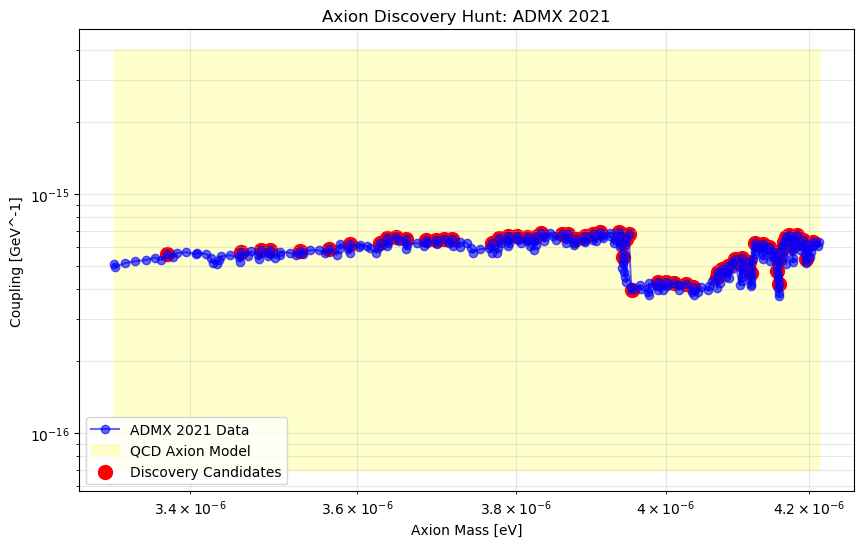

In [11]:
import io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# 1. YOUR COPIED DATA
raw_data = """# ADMX 2021
# https://arxiv.org/pdf/2110.06096.pdf
0.000003312870397404704	1e0
0.000003312870397404704	5.101847784044922e-16
0.000003314263179237632	4.970121044099702e-16
0.0000033252744886005226	5.152404614127314e-16
0.000003336572897285435	5.243892741276483e-16
0.0000033485470397404705	5.301250487718403e-16
0.000003359903568532036	5.437471728439339e-16
0.0000033666412994503023	5.317615613650933e-16
0.000003373121603811841	5.600764424897485e-16
0.0000033798846309813465	5.487879430281759e-16
0.000003384384387672344	5.680991760093389e-16
0.0000033952111832026676	5.719922349630926e-16
0.0000034062671330089214	5.621588316206591e-16
0.0000034074724249797244	5.6919426743174855e-16
0.0000034187218167072182	5.6272296734249895e-16
0.000003423864395782644	5.407015742459766e-16
0.0000034268761376948723	5.155161581315754e-16
0.000003431042579075426	5.107582292843143e-16
0.0000034342566909975673	5.313468844831559e-16
0.0000034362733886742044	5.512412569025812e-16
0.0000034471131386861314	5.550228060973126e-16
0.0000034568224351175994	5.456046496855297e-16
0.000003458898215733982	5.223635734461769e-16
0.0000034601124357934577	5.707492614386894e-16
0.0000034680460727431527	5.536361835345515e-16
0.0000034711296972154637	5.777840186037985e-16
0.000003479407310856216	5.578472093172236e-16
0.0000034805041903217087	5.352337881147397e-16
0.000003483386687521724	5.852721252219346e-16
0.000003491421967327077	5.51594484149004e-16
0.000003494100393928861	5.641923710770553e-16
0.0000034942534468775347	5.853209198413979e-16
0.000003500069458927123	5.412596881952157e-16
0.000003505562359196179	5.565981086658495e-16
0.000003505949243038659	5.744709431288468e-16
0.00000351765443718786	5.69218306233573e-16
0.000003524864036612212	5.573784684111086e-16
0.000003530613087996756	5.78170497886359e-16
0.000003533298954672434	5.630868214121615e-16
0.0000035421303223844285	5.839988060545087e-16
0.0000035531788321167885	5.823822237696543e-16
0.0000035597856177345233	5.678257325125412e-16
0.0000035655353068396866	5.907542787355072e-16
0.0000035746062449310627	5.587858740579791e-16
0.0000035769096918085972	5.883731516282252e-16
0.0000035788917274939175	6.219450270269398e-16
0.000003588092910643576	5.920197056415369e-16
0.0000035903706986444216	5.705661007006395e-16
0.000003591123208975399	6.177400202986823e-16
0.0000036016285933135083	6.005789804557961e-16
0.000003602997566909976	6.140335751518017e-16
0.0000036122113544201133	6.059574882399104e-16
0.000003615139767504731	5.934465512274958e-16
0.000003623430135557873	5.692595179701221e-16
0.000003625837241023372	5.980966847973288e-16
0.0000036281078163017034	6.231541416463587e-16
0.0000036362100567721007	6.059574882399104e-16
0.0000036365076597278543	6.532559227791253e-16
0.000003638011907395119	6.27413165337254e-16
0.000003647727291159773	6.627596225685971e-16
0.0000036510682759209458	6.385627340002934e-16
0.000003660315896188159	6.479855803631236e-16
0.0000036605837388483376	5.885856426093115e-16
0.000003661642355076662	6.154076516038521e-16
0.000003673922303325223	6.251198358334949e-16
0.000003682636117869694	6.088818830480938e-16
0.000003685272529936549	6.417847715391693e-16
0.0000036869662408759125	6.244680920939393e-16
0.0000036980281427412815	6.438196174059448e-16
0.0000036994696232396963	6.199520057172983e-16
0.0000037080990267639905	6.505358677517205e-16
0.000003714717716499955	6.261685071063302e-16
0.0000037178127872397947	6.525573904325094e-16
0.000003719619412241782	6.071312882767211e-16
0.0000037278122465531225	6.006325285118334e-16
0.0000037279461678832116	6.296253404379248e-16
0.000003736870198333702	6.255851315726952e-16
0.0000037418070255474453	5.984676464465333e-16
0.0000037445970532576373	5.698797712760898e-16
0.000003753346580156799	5.881528716383316e-16
0.0000037655653072258914	5.939229302108424e-16
0.0000037690600162206003	5.705661007006395e-16
0.000003769442648592284	6.240745105406833e-16
0.000003775666801838335	5.705661007006395e-16
0.00000377763098134631	5.958322732652678e-16
0.0000037786487834549877	6.585892625996266e-16
0.000003780886299831555	6.230627975160304e-16
0.0000037899517437145173	6.709643430065964e-16
0.0000037903981481481484	6.464770064940165e-16
0.0000037905945660989455	6.086864850640416e-16
0.000003791773073803731	6.26023373343801e-16
0.0000038015582589889158	6.697092773179692e-16
0.000003802607309407948	6.415462612786973e-16
0.0000038067722627737228	6.265259028092226e-16
0.0000038141171037217266	6.371499839540047e-16
0.000003814164720194647	6.615552924629785e-16
0.000003818021654501217	6.055362381761447e-16
0.0000038231642335766425	5.863465470915995e-16
0.000003823699918896999	6.355897263932634e-16
0.0000038253069748580695	6.652085750158641e-16
0.000003826378345498784	6.141156984984137e-16
0.000003833036148766076	6.86052555178155e-16
0.000003837306326034063	6.377865313873928e-16
0.000003838788388753717	6.603708135174811e-16
0.000003844591646390917	6.906290037157208e-16
0.0000038490031725585615	6.660419769280056e-16
0.000003853028690186537	6.465202362801427e-16
0.0000038603050824547175	6.808167115070271e-16
0.000003865893015600401	6.521673595077479e-16
0.000003866447607461477	6.265259028092226e-16
0.000003868697485806975	6.81818988713347e-16
0.000003876411354420113	6.233166711490217e-16
0.0000038770006082725066	6.152665792882385e-16
0.000003878804082184374	6.497707225314253e-16
0.00000388909473454364	6.386374186319009e-16
0.000003890534540336816	6.664193350097187e-16
0.000003890660583941606	6.317761828646144e-16
0.000003901629378596532	6.796341014407214e-16
0.000003901951182232204	6.456130175350251e-16
0.000003905659772911598	6.389134126086323e-16
0.0000039113737496620705	6.971246554704895e-16
0.000003913159367396593	6.697907037696705e-16
0.000003914689896883327	6.533557741362169e-16
0.0000039245323788134004	6.902880613606256e-16
0.000003924623033252231	6.660294020059646e-16
0.000003929497769667477	6.224669856284952e-16
0.000003931678774186073	6.438392980028217e-16
0.000003936976760870922	6.942190812658975e-16
0.000003937158069748581	6.017903325674808e-16
0.000003937800892133009	6.709643430065964e-16
0.00000394101500405515	4.934357629493855e-16
0.000003941372127602054	5.463713361558673e-16
0.0000039418185320356855	5.152864006247202e-16
0.000003942086374695864	6.246184341587744e-16
0.000003943514868883482	4.731440349132984e-16
0.000003944994380720658	4.504566070754246e-16
0.000003945695202117215	6.526308849645577e-16
0.0000039463718572587185	4.2902094735870184e-16
0.000003949432916232186	6.841677344199187e-16
0.000003953004151701232	4.1029500494527484e-16
0.0000039536928899702626	3.959407871283935e-16
0.00000396484024639864	4.182090565188928e-16
0.000003965962634688912	4.0065863620006455e-16
0.0000039754519175066615	3.919368787845521e-16
0.0000039766380778588805	3.777338735820471e-16
0.00000397705201651552	4.0691131748764614e-16
0.000003977155907001892	4.236387767603976e-16
0.000003988544901570449	4.1367521529544796e-16
0.000003988814617256223	4.292151841946766e-16
0.000003988934490894344	3.9787097447205934e-16
0.000003995654906731549	3.963646233322412e-16
0.000004000105215546822	4.287915080566812e-16
0.000004001011759935117	4.1232553124267844e-16
0.000004011230987585002	4.2652140359838e-16
0.000004018019768856448	3.99237409097623e-16
0.000004018086729521492	4.159977286864671e-16
0.000004028197789943228	4.2196509227908165e-16
0.000004035831305758313	3.8974158937776477e-16
0.000004036682100090645	4.077502817415583e-16
0.000004038688294133549	3.794553380787817e-16
0.000004044295133819951	3.919368787845521e-16
0.000004048546783625731	4.0784348389242036e-16
0.000004058222952149229	3.9585607428855603e-16
0.000004060034542505345	4.1262039784810545e-16
0.000004064008353609083	4.334500668231718e-16
0.000004070524807976719	4.500679869443956e-16
0.000004070710372172659	4.0457640480935566e-16
0.0000040724639403581006	4.713756206548408e-16
0.000004073984004685951	4.265799110899607e-16
0.0000040780165247364155	4.867993388672582e-16
0.000004082600754881777	4.50997121935086e-16
0.000004084816752275389	4.704519478329996e-16
0.000004085721465260881	5.011234431717319e-16
0.000004087792781832928	4.484987106654688e-16
0.000004091721140848878	4.881847275782221e-16
0.000004091792565558259	5.182442867033354e-16
0.00000409513932336925	5.369339406962421e-16
0.0000041022562854825625	4.1708399786610555e-16
0.00000410362525907903	5.126743914609583e-16
0.0000041049347120843475	4.3447149640095022e-16
0.000004105202554744526	4.517493557431265e-16
0.000004106006082725061	5.39558958000764e-16
0.000004106095363611787	4.886419536701601e-16
0.000004107220302784536	4.669584677915651e-16
0.000004115172253762278	5.194377471681464e-16
0.000004117505460935388	4.9177562171982e-16
0.000004117638106824238	4.2264281458460136e-16
0.000004117638106824238	4.119286970088786e-16
0.000004117638106824238	4.3783121607698755e-16
0.000004117791159772911	4.691953101712764e-16
0.000004117791159772911	4.529996543834613e-16
0.000004121297463687974	5.38615170793078e-16
0.0000041231480129764795	6.232166479776095e-16
0.0000041231480129764795	6.015972103526809e-16
0.0000041232670541587815	5.599435965585874e-16
0.0000041234541188738265	5.775632893012386e-16
0.000004134575966477426	5.771661890330609e-16
0.000004134835692693357	5.5822326147551e-16
0.0000041349330900243306	6.204949227359355e-16
0.0000041349330900243306	5.989699019872017e-16
0.000004135097916276749	5.35817755140799e-16
0.00000414350405515004	6.015972103526809e-16
0.0000041447896999188975	5.272484137472449e-16
0.000004145799849380141	5.612987515978588e-16
0.000004147010359065103	5.8021963105366155e-16
0.000004152610705596107	5.489991735349094e-16
0.000004154386925342553	5.02244951784066e-16
0.000004155289132197891	4.77875266075135e-16
0.0000041557652969270975	4.0399968478803196e-16
0.000004155824817518248	4.577334553041953e-16
0.000004156360502838605	5.301047930621711e-16
0.000004156360502838605	4.4175223009917335e-16
0.000004157342592592593	4.2196509227908165e-16
0.000004157431873479318	3.7471502441488605e-16
0.000004157431873479318	3.877363403490439e-16
0.000004159574614760746	5.793570299404503e-16
0.000004161230369387304	6.099043029779326e-16
0.000004164127939983779	6.331718180984536e-16
0.000004164127939983779	5.461521730109231e-16
0.000004167788456339551	6.638240873492865e-16
0.000004167877737226278	5.111682316434131e-16
0.000004171665797705943	6.783887393837974e-16
0.000004175645174371452	5.763126137089318e-16
0.0000041767165450121655	6.074179257205123e-16
0.000004177175703858185	5.4250200481706885e-16
0.000004177787915652879	5.219445914278098e-16
0.000004178502162746688	6.502053536644933e-16
0.000004179287834549878	6.293475317719551e-16
0.000004183721660739908	6.722909178868416e-16
0.000004187235456757354	5.842970866006609e-16
0.000004188903386050283	6.086376453665823e-16
0.000004191228747327288	6.428872682044404e-16
0.000004194365966619713	5.611800786390883e-16
0.000004195806421883064	5.357155399878654e-16
0.000004196179778318465	5.172195507031824e-16
0.000004196215490673155	6.214189730583482e-16
0.000004199674487313173	5.88298966501713e-16
0.000004202215166261152	5.479519091512095e-16
0.000004203500811030008	5.73056875576105e-16
0.000004205911394971614	6.338919844851516e-16
0.000004206286374695864	6.093054605582232e-16
0.000004213602305642452	6.079752082514148e-16
0.000004214393079210598	6.321142359363431e-16
0.000004214393079210598	1e0"""

# 2. ANALYSIS ENGINE
def analyze_axion_string(data_string):
    # Load data from the string variable
    data = np.loadtxt(io.StringIO(data_string))
    mass = data[:, 0]
    coupling = data[:, 1]
    
    # We ignore the '1e0' points (they are just the chart borders)
    valid = coupling < 1e-10
    m, c = mass[valid], coupling[valid]

    # TRANSIENT HUNTER: Find sharp changes in the coupling
    # We look for where the experiment got 'more sensitive' suddenly
    baseline = savgol_filter(c, window_length=5, polyorder=2)
    ratio = c / baseline
    peaks, _ = find_peaks(ratio, height=1.02) # Looking for 2% deviations

    # PLOT
    plt.figure(figsize=(10, 6))
    plt.loglog(m, c, label='ADMX 2021 Data', marker='o', color='blue', alpha=0.6)
    
    # THEORY: The QCD Axion "Yellow Band" (The discovery zone)
    plt.fill_between(m, 0.7e-16, 4e-15, color='yellow', alpha=0.2, label='QCD Axion Model')

    if len(peaks) > 0:
        plt.scatter(m[peaks], c[peaks], color='red', s=100, label='Discovery Candidates')
        print(f" FOUND {len(peaks)} POTENTIAL CANDIDATES!")
        for p in peaks:
            print(f"   Check Mass: {m[p]:.4e} eV")
    
    plt.xlabel('Axion Mass [eV]')
    plt.ylabel('Coupling [GeV^-1]')
    plt.title('Axion Discovery Hunt: ADMX 2021')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

# 3. RUN IT
analyze_axion_string(raw_data)


 FOUND 98 POTENTIAL CANDIDATES!
   Check Mass: 3.2738e-06 eV
   Check Mass: 3.2754e-06 eV
   Check Mass: 3.2756e-06 eV
   Check Mass: 3.2766e-06 eV
   Check Mass: 3.2774e-06 eV
   Check Mass: 3.2779e-06 eV
   Check Mass: 3.2789e-06 eV
   Check Mass: 3.2792e-06 eV
   Check Mass: 3.2795e-06 eV
   Check Mass: 3.2800e-06 eV
   Check Mass: 3.2804e-06 eV
   Check Mass: 3.2809e-06 eV
   Check Mass: 3.2813e-06 eV
   Check Mass: 3.2817e-06 eV
   Check Mass: 3.2827e-06 eV
   Check Mass: 3.2828e-06 eV
   Check Mass: 3.2833e-06 eV
   Check Mass: 3.2836e-06 eV
   Check Mass: 3.2838e-06 eV
   Check Mass: 3.2841e-06 eV
   Check Mass: 3.2850e-06 eV
   Check Mass: 3.2854e-06 eV
   Check Mass: 3.2861e-06 eV
   Check Mass: 3.2864e-06 eV
   Check Mass: 3.2869e-06 eV
   Check Mass: 3.2871e-06 eV
   Check Mass: 3.2884e-06 eV
   Check Mass: 3.2887e-06 eV
   Check Mass: 3.2894e-06 eV
   Check Mass: 3.2902e-06 eV
   Check Mass: 3.2910e-06 eV
   Check Mass: 3.2917e-06 eV
   Check Mass: 3.2923e-06 eV
   Check Ma

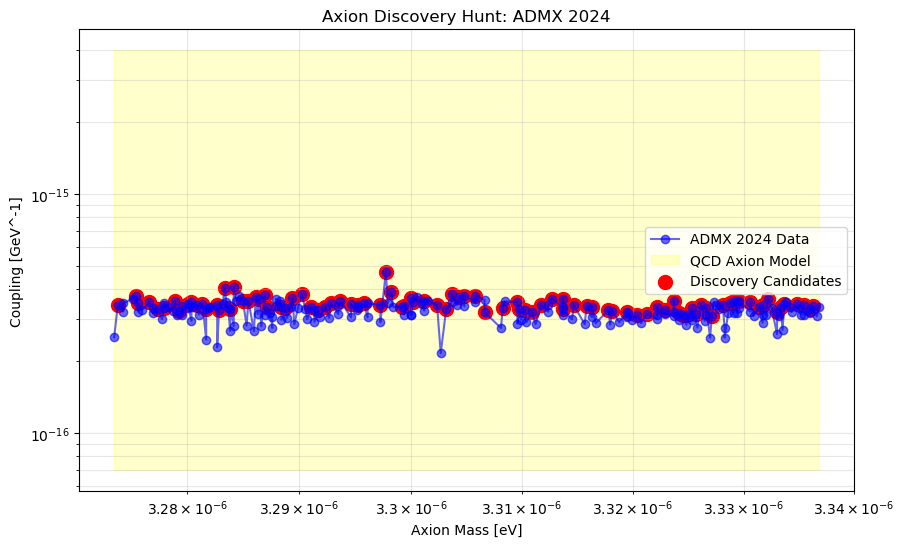

In [12]:
import io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# 1. YOUR COPIED DATA
raw_data = """# ADMX DFSZ 3.3 micro eV run
# https://arxiv.org/pdf/2408.15227
# mass [eV] photon coupling [GeV^-1]
0.0000032734682713347918	1.0
0.0000032734682713347918	2.523598159639272e-16
0.0000032737964989059078	3.4464639280847735e-16
0.000003274288840262582	3.2291699999439034e-16
0.000003274288840262582	3.494896698159091e-16
0.0000032751094091903714	3.66130883536404e-16
0.0000032754376367614874	3.7474631737480915e-16
0.0000032756017505470455	3.2291699999439034e-16
0.0000032756017505470455	3.494896698159091e-16
0.0000032759299781181615	3.2745491628777315e-16
0.0000032765864332603935	3.5275627462507425e-16
0.0000032769146608315095	3.3516026509388476e-16
0.0000032769146608315095	3.184419707833552e-16
0.0000032774070021881836	3.305155669928264e-16
0.0000032777352297592996	2.9975585640098997e-16
0.0000032778993435448576	3.3516026509388476e-16
0.0000032778993435448576	3.494896698159091e-16
0.000003278227571115973	3.3672295752114225e-16
0.000003278719912472647	3.244226079171643e-16
0.0000032788840262582052	3.5771351888982945e-16
0.0000032790481400437632	3.1112097627732677e-16
0.0000032792122538293212	3.259352357714276e-16
0.0000032795404814004373	3.140289571566342e-16
0.0000032795404814004373	3.398702346151254e-16
0.0000032800328227571113	3.3516026509388476e-16
0.0000032800328227571113	3.4786772854868135e-16
0.0000032803610503282273	2.956017975759774e-16
0.0000032803610503282273	3.5440100885056553e-16
0.0000032805251641137853	3.3672295752114225e-16
0.0000032808533916849013	3.4464639280847735e-16
0.0000032810175054704593	3.140289571566342e-16
0.000003281345733041575	3.4786772854868135e-16
0.000003281673960612691	2.465580530189567e-16
0.000003281673960612691	3.305155669928264e-16
0.000003281838074398249	3.3360482494202953e-16
0.000003282002188183807	3.3672295752114225e-16
0.000003282658643326039	3.4464639280847735e-16
0.000003282658643326039	2.2887373639833753e-16
0.000003282822757111597	3.289816823494012e-16
0.000003283150984682713	3.4786772854868135e-16
0.000003283315098468271	4.037017258596566e-16
0.000003283479212253829	3.5275627462507425e-16
0.000003283643326039387	3.3516026509388476e-16
0.000003283807439824945	2.6809136644381527e-16
0.000003283807439824945	3.3205660340860253e-16
0.000003284135667396061	2.8085673867344774e-16
0.000003284135667396061	4.0747503910195253e-16
0.000003284299781181619	3.5771351888982945e-16
0.0000032846280087527347	3.7474631737480915e-16
0.0000032849562363238507	3.5771351888982945e-16
0.0000032852844638949667	2.821662396626127e-16
0.0000032854485776805247	3.5771351888982945e-16
0.0000032859409190371988	2.6809136644381527e-16
0.0000032861050328227568	3.7127607967640083e-16
0.000003286269146608315	3.15493124375713e-16
0.000003286433260393873	3.644317123147581e-16
0.000003286597374179431	2.8085673867344774e-16
0.000003286925601750547	3.782489906389398e-16
0.000003286925601750547	3.140289571566342e-16
0.000003287089715536105	3.3672295752114225e-16
0.000003287417943107221	3.184419707833552e-16
0.0000032875820568927784	2.7567922576405317e-16
0.0000032875820568927784	3.053855508833425e-16
0.0000032879102844638945	3.4145488738336146e-16
0.0000032879102844638945	3.644317123147581e-16
0.0000032882385120350105	3.5771351888982945e-16
0.0000032884026258205685	3.382929360377039e-16
0.0000032884026258205685	2.9836472402833465e-16
0.0000032887308533916845	3.3360482494202953e-16
0.0000032888949671772425	3.0396829174760414e-16
0.0000032892231947483585	3.3672295752114225e-16
0.0000032893873085339165	3.6783797718286495e-16
0.0000032895514223194746	2.8613149010291214e-16
0.0000032898796498905906	3.3360482494202953e-16
0.0000032902078774617066	3.817844026370508e-16
0.0000032905361050328226	3.3205660340860253e-16
0.00000329070021881838	2.9975585640098997e-16
0.0000032910284463894962	3.3672295752114225e-16
0.0000032913566739606122	3.289816823494012e-16
0.0000032913566739606122	2.928644564625249e-16
0.0000032916849015317283	3.2745491628777315e-16
0.0000032918490153172863	3.053855508833425e-16
0.0000032923413566739603	3.382929360377039e-16
0.0000032926695842450763	3.0396829174760414e-16
0.0000032928336980306343	3.494896698159091e-16
0.0000032934901531728664	3.15493124375713e-16
0.0000032934901531728664	3.4145488738336146e-16
0.0000032936542669584244	3.5938136638046407e-16
0.000003294638949671772	3.053855508833425e-16
0.000003294638949671772	3.4786772854868135e-16
0.000003295131291028446	3.2745491628777315e-16
0.000003295295404814004	3.4464639280847735e-16
0.000003295295404814004	3.382929360377039e-16
0.000003295787746170678	3.494896698159091e-16
0.000003296115973741794	3.053855508833425e-16
0.000003296115973741794	3.494896698159091e-16
0.0000032972647702406997	3.4464639280847735e-16
0.0000032972647702406997	2.9150530628251816e-16
0.0000032977571115973738	4.728762199830476e-16
0.0000032979212253829318	3.511191734215142e-16
0.0000032982494529540478	3.889546697029888e-16
0.000003298413566739606	3.382929360377039e-16
0.000003299234135667396	3.382929360377039e-16
0.000003299398249452954	3.140289571566342e-16
0.000003299398249452954	3.4145488738336146e-16
0.0000033000547045951855	3.125715849688248e-16
0.0000033000547045951855	3.6783797718286495e-16
0.0000033000547045951855	3.140289571566342e-16
0.0000033002188183807435	3.5275627462507425e-16
0.0000033005470459518595	3.7300716291793648e-16
0.0000033010393873085335	3.4786772854868135e-16
0.0000033012035010940915	3.259352357714276e-16
0.0000033012035010940915	3.5771351888982945e-16
0.0000033015317286652076	3.5938136638046407e-16
0.0000033023522975929976	3.430469286314926e-16
0.0000033026805251641136	2.164479791214133e-16
0.0000033031728665207872	3.305155669928264e-16
0.0000033036652078774612	3.5275627462507425e-16
0.0000033036652078774612	3.817844026370508e-16
0.0000033041575492341353	3.4464639280847735e-16
0.0000033043216630196933	3.7127607967640083e-16
0.0000033048140043763673	3.398702346151254e-16
0.0000033048140043763673	3.7649358067924713e-16
0.0000033057986870897154	3.5440100885056553e-16
0.0000033057986870897154	3.7649358067924713e-16
0.000003306619256017505	3.61056990248296e-16
0.000003306619256017505	3.2141837942441553e-16
0.000003306947483588621	1.0
0.000003307768052516411 1.0
0.000003308096280087527	2.7567922576405317e-16
0.000003308260393873085	3.3516026509388476e-16
0.000003308424507658643	3.560534116871251e-16
0.0000033095733041575487	3.5440100885056553e-16
0.0000033095733041575487	2.8746558474166193e-16
0.0000033097374179431067	3.3205660340860253e-16
0.0000033099015317286648	2.9836472402833465e-16
0.0000033102297592997808	3.289816823494012e-16
0.0000033103938730853388	2.9150530628251816e-16
0.000003310886214442013	3.2291699999439034e-16
0.000003311214442013129	2.8613149010291214e-16
0.000003311706783369803	3.4464639280847735e-16
0.000003312363238512035	3.2291699999439034e-16
0.000003312363238512035	3.430469286314926e-16
0.0000033126914660831505	3.66130883536404e-16
0.0000033136761487964986	3.3672295752114225e-16
0.0000033136761487964986	3.66130883536404e-16
0.0000033136761487964986	3.140289571566342e-16
0.0000033136761487964986	3.305155669928264e-16
0.0000033144967177242886	2.9975585640098997e-16
0.0000033146608315098466	3.430469286314926e-16
0.0000033156455142231947	2.8613149010291214e-16
0.0000033158096280087522	3.398702346151254e-16
0.0000033163019693654263	3.053855508833425e-16
0.0000033163019693654263	3.382929360377039e-16
0.0000033166301969365423	2.8880589962727974e-16
0.0000033177789934354484	3.2745491628777315e-16
0.0000033179431072210064	2.8480358684358047e-16
0.0000033181072210065644	3.244226079171643e-16
0.000003318763676148796	2.9150530628251816e-16
0.000003319420131291028	3.2141837942441553e-16
0.000003319420131291028	3.053855508833425e-16
0.000003319584245076586	3.184419707833552e-16
0.000003319912472647702	2.969800477406462e-16
0.000003320404814004376	3.125715849688248e-16
0.000003320733041575492	2.8880589962727974e-16
0.000003321225382932166	3.15493124375713e-16
0.0000033222100656455138	3.0115347496025777e-16
0.0000033222100656455138	3.3672295752114225e-16
0.0000033222100656455138	3.140289571566342e-16
0.000003322866520787746	3.289816823494012e-16
0.000003322866520787746	3.169641183080518e-16
0.000003323687089715536	3.096770996935361e-16
0.000003323687089715536	3.5938136638046407e-16
0.000003323687089715536	3.2141837942441553e-16
0.00000332417943107221	3.1992671377973843e-16
0.00000332417943107221	2.9836472402833465e-16
0.000003324507658643326	3.1112097627732677e-16
0.000003324835886214442	2.8480358684358047e-16
0.000003324835886214442	3.140289571566342e-16
0.0000033251641137855575	3.053855508833425e-16
0.0000033253282275711155	3.3360482494202953e-16
0.0000033253282275711155	2.9836472402833465e-16
0.0000033256564551422315	3.169641183080518e-16
0.0000033258205689277896	2.769645864804645e-16
0.0000033261487964989056	3.430469286314926e-16
0.0000033264770240700216	2.956017975759774e-16
0.0000033266411378555796	3.125715849688248e-16
0.0000033266411378555796	3.3360482494202953e-16
0.0000033269693654266956	2.511886431509582e-16
0.0000033271334792122536	3.082399239745156e-16
0.0000033272975929978116	3.5440100885056553e-16
0.0000033274617067833696	3.4464639280847735e-16
0.0000033277899343544857	3.305155669928264e-16
0.0000033281181619256017	3.4464639280847735e-16
0.0000033282822757111593	2.7567922576405317e-16
0.0000033282822757111593	2.511886431509582e-16
0.0000033286105032822753	3.184419707833552e-16
0.0000033287746170678333	3.494896698159091e-16
0.0000033291028446389493	3.1992671377973843e-16
0.0000033291028446389493	3.560534116871251e-16
0.0000033294310722100653	3.184419707833552e-16
0.0000033294310722100653	3.560534116871251e-16
0.0000033295951859956233	3.3360482494202953e-16
0.0000033295951859956233	3.5938136638046407e-16
0.0000033305798687089714	3.2291699999439034e-16
0.0000033305798687089714	3.5275627462507425e-16
0.0000033309080962800874	3.096770996935361e-16
0.000003331400437636761	3.3672295752114225e-16
0.000003331728665207877	2.9015246376181047e-16
0.000003331728665207877	3.125715849688248e-16
0.000003331728665207877	3.430469286314926e-16
0.000003332056892778993	3.1112097627732677e-16
0.000003332221006564551	3.644317123147581e-16
0.000003332549234135667	3.3360482494202953e-16
0.000003333041575492341	2.5950242113997425e-16
0.000003333041575492341	3.2291699999439034e-16
0.000003333205689277899	3.096770996935361e-16
0.000003333369803063457	3.382929360377039e-16
0.000003333533916849015	2.7059715881067604e-16
0.000003333698030634573	3.4625331452389316e-16
0.000003333862144420131	3.5275627462507425e-16
0.000003334190371991247	3.3672295752114225e-16
0.000003334354485776805	3.2141837942441553e-16
0.000003334846827133479	3.4625331452389316e-16
0.000003335010940919037	3.3360482494202953e-16
0.000003335175054704595	3.140289571566342e-16
0.000003335503282275711	3.4464639280847735e-16
0.000003335503282275711	3.140289571566342e-16
0.000003335995623632385	3.3205660340860253e-16
0.000003335995623632385	3.184419707833552e-16
0.000003336323851203501	3.398702346151254e-16
0.000003336652078774617	3.082399239745156e-16
0.000003336816192560175	3.3672295752114225e-16"""

# 2. ANALYSIS ENGINE
def analyze_axion_string(data_string):
    # Load data from the string variable
    data = np.loadtxt(io.StringIO(data_string))
    mass = data[:, 0]
    coupling = data[:, 1]
    
    # We ignore the '1e0' points (they are just the chart borders)
    valid = coupling < 1e-10
    m, c = mass[valid], coupling[valid]

    # TRANSIENT HUNTER: Find sharp changes in the coupling
    # We look for where the experiment got 'more sensitive' suddenly
    baseline = savgol_filter(c, window_length=5, polyorder=2)
    ratio = c / baseline
    peaks, _ = find_peaks(ratio, height=1.02) # Looking for 2% deviations

    # PLOT
    plt.figure(figsize=(10, 6))
    plt.loglog(m, c, label='ADMX 2024 Data', marker='o', color='blue', alpha=0.6)
    
    # THEORY: The QCD Axion "Yellow Band" (The discovery zone)
    plt.fill_between(m, 0.7e-16, 4e-15, color='yellow', alpha=0.2, label='QCD Axion Model')

    if len(peaks) > 0:
        plt.scatter(m[peaks], c[peaks], color='red', s=100, label='Discovery Candidates')
        print(f" FOUND {len(peaks)} POTENTIAL CANDIDATES!")
        for p in peaks:
            print(f"   Check Mass: {m[p]:.4e} eV")
    
    plt.xlabel('Axion Mass [eV]')
    plt.ylabel('Coupling [GeV^-1]')
    plt.title('Axion Discovery Hunt: ADMX 2024')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

# 3. RUN IT
analyze_axion_string(raw_data)


 FOUND 89 POTENTIAL CANDIDATES!
   Check Mass: 4.5113e-06 eV
   Check Mass: 4.5159e-06 eV
   Check Mass: 4.5250e-06 eV
   Check Mass: 4.5284e-06 eV
   Check Mass: 4.5319e-06 eV
   Check Mass: 4.5365e-06 eV
   Check Mass: 4.6292e-06 eV
   Check Mass: 4.6397e-06 eV
   Check Mass: 4.6479e-06 eV
   Check Mass: 4.6503e-06 eV
   Check Mass: 4.6574e-06 eV
   Check Mass: 4.6668e-06 eV
   Check Mass: 4.6703e-06 eV
   Check Mass: 4.6774e-06 eV
   Check Mass: 4.6845e-06 eV
   Check Mass: 4.6928e-06 eV
   Check Mass: 4.6976e-06 eV
   Check Mass: 4.7059e-06 eV
   Check Mass: 4.8094e-06 eV
   Check Mass: 4.8142e-06 eV
   Check Mass: 4.8203e-06 eV
   Check Mass: 4.8301e-06 eV
   Check Mass: 4.9040e-06 eV
   Check Mass: 4.9077e-06 eV
   Check Mass: 4.9238e-06 eV
   Check Mass: 4.9301e-06 eV
   Check Mass: 4.9413e-06 eV
   Check Mass: 4.9526e-06 eV
   Check Mass: 4.9601e-06 eV
   Check Mass: 4.9764e-06 eV
   Check Mass: 4.9827e-06 eV
   Check Mass: 4.9890e-06 eV
   Check Mass: 4.9941e-06 eV
   Check Ma

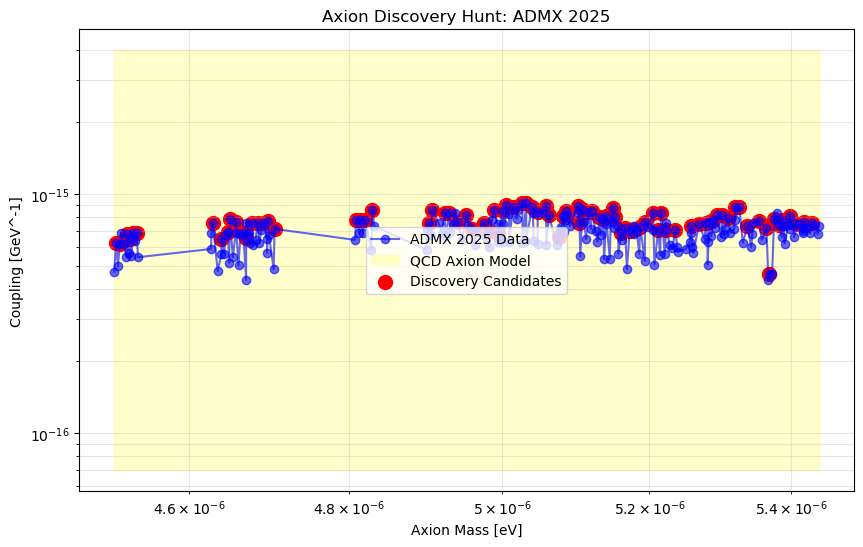

In [13]:
import io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# 1. YOUR COPIED DATA
raw_data = """# ADMX 2025
# https://arxiv.org/pdf/2504.07279
# mass [eV]  photon coupling [GeV^-1]
0.0000045090058589701714	1.0
0.0000045090058589701714	4.737903162030171e-16
0.000004511287148645969	6.276513129035214e-16
0.0000045135695925191195	4.994430556546347e-16
0.00000451585319117356	6.2215960243524005e-16
0.0000045169954237263385	6.853063774588078e-16
0.000004520423855163655	6.2215960243524005e-16
0.000004523854888804644	5.45321110911543e-16
0.000004524999145293791	6.793102070857061e-16
0.000004527288526624405	5.698170980868798e-16
0.0000045284336516123116	6.501071975994741e-16
0.000004529579066246268	5.501345794196972e-16
0.0000045318707647454	6.853063774588078e-16
0.000004534163622708114	6.387805852570497e-16
0.000004536457640721047	6.853063774588078e-16
0.000004537605084929743	5.45321110911543e-16
0.0000045387528193711	1.0
0.00000462566546081645	1.0
0.0000046268354691059	5.902038108832405e-16
0.000004627420584223443	6.91355475137827e-16
0.0000046291763735796274	7.548623040574235e-16
0.00000463503381764498	4.779723930030505e-16
0.000004639725108806648	5.598893547855486e-16
0.000004639725108806648	6.501071975994741e-16
0.000004643246692941965	5.648314150201251e-16
0.00000464442114819964	6.733665009247083e-16
0.000004647946296662032	6.974579673042402e-16
0.000004649121940629819	5.173119510737999e-16
0.000004650297881963077	7.887709442133645e-16
0.000004653827490907912	5.45321110911543e-16
0.000004657359778850882	6.91355475137827e-16
0.000004657359778850882	7.682472329160975e-16
0.000004660894747825345	5.038515653783667e-16
0.000004663252884275108	6.793102070857061e-16
0.00000466679232615822	6.853063774588078e-16
0.000004670334454502736	4.377604088735241e-16
0.000004670334454502736	6.558455973422241e-16
0.000004670334454502736	7.615253615768718e-16
0.000004673879271347679	6.91355475137827e-16
0.000004675061474759855	6.276513129035214e-16
0.000004677426778733651	7.615253615768718e-16
0.000004678609879446568	6.113199122150372e-16
0.000004682160977397515	6.444190066737732e-16
0.000004684529873298795	7.615253615768718e-16
0.000004686899967720985	6.276513129035214e-16
0.000004689271261270445	7.098250244802368e-16
0.000004692830451285515	7.615253615768718e-16
0.000004696392342750941	6.501071975994741e-16
0.000004696392342750941	5.698170980868798e-16
0.000004697580240582739	7.750284372159614e-16
0.00000469876843887948	6.733665009247083e-16
0.000004704713939997965	4.864476161561587e-16
0.000004705903942681019	7.160905446173979e-16
0.000004707094246361405	1.0
0.000004805730733743206	1.0
0.000004807554179595463	6.444190066737732e-16
0.000004809378317320612	7.818694981996946e-16
0.000004813028669439731	6.853063774588078e-16
0.000004814246069074066	7.818694981996946e-16
0.000004817900115851154	6.91355475137827e-16
0.000004820337687710027	7.818694981996946e-16
0.000004823996358068695	1.0
0.00000482643701426475	1.0
0.000004828878905288172	5.8503975182686e-16
0.000004830100314055363	8.612262052365313e-16
0.0000048325440584913116	7.352208909053295e-16
0.000004833766394316386	1.0
0.0000048989945693795945	1.0
0.000004900233713088688	5.8503975182686e-16
0.000004901473170224773	7.098250244802368e-16
0.000004903953025095051	7.615253615768718e-16
0.00000490643413462488	6.733665009247083e-16
0.000004907675160085492	8.612262052365313e-16
0.000004916371132040324	7.548623040574235e-16
0.000004920102692461665	6.91355475137827e-16
0.000004923837085163728	8.314778861387913e-16
0.000004925082512498312	6.674747999338962e-16
0.000004930067372797153	8.388172180298041e-16
0.000004931314376010546	6.974579673042402e-16
0.000004935057278459639	7.482575457591797e-16
0.000004937554124897845	8.314778861387913e-16
0.000004941301763360424	7.682472329160975e-16
0.000004946303039769959	6.444190066737732e-16
0.0000049525617542901255	8.169913095828475e-16
0.0000049550674569554564	7.417105765861098e-16
0.000004960082666138577	7.160905446173979e-16
0.000004963847403923102	6.113199122150372e-16
0.000004966358816458157	6.974579673042402e-16
0.000004967614999170203	1.0
0.000004975158770729122	1.0
0.000004976417179287282	7.615253615768718e-16
0.000004978934951383538	6.616346490877935e-16
0.0000049827139981857585	7.036143252632571e-16
0.0000049827139981857585	6.006690784934106e-16
0.000004986495913311189	7.818694981996946e-16
0.0000049890187846494155	8.612262052365313e-16
0.000004994068357241684	7.482575457591797e-16
0.000004994068357241684	6.793102070857061e-16
0.000004994068357241684	6.331914978850135e-16
0.000005000387510736903	8.536908032233041e-16
0.00000500165230061148	7.482575457591797e-16
0.00000500165230061148	6.331914978850135e-16
0.000005005448590042243	8.999127436015572e-16
0.000005009247760883513	8.242027706127368e-16
0.000005009247760883513	6.331914978850135e-16
0.000005014317807979562	8.842338481418237e-16
0.000005019392986659987	7.887709442133645e-16
0.000005020662583748697	8.612262052365313e-16
0.000005027015387764366	9.158696512221618e-16
0.000005027015387764366	6.276513129035214e-16
0.0000050321034181404135	9.158696512221618e-16
0.0000050321034181404135	6.387805852570497e-16
0.000005039745121181742	8.842338481418237e-16
0.000005041019866106217	8.314778861387913e-16
0.000005042294933462586	6.387805852570497e-16
0.0000050473984288385795	6.2215960243524005e-16
0.0000050473984288385795	8.462213331140978e-16
0.000005053785062569195	8.388172180298041e-16
0.000005058900187534787	8.920388490792715e-16
0.000005058900187534787	6.113199122150372e-16
0.000005062739928516156	8.169913095828475e-16
0.000005064020489709755	1.0
0.000005070428155862544	1.0
0.000005072993491940091	6.113199122150372e-16
0.000005075560125925613	6.616346490877935e-16
0.000005078128058475795	7.098250244802368e-16
0.000005079412511917928	7.287879875080501e-16
0.000005081982393547047	8.098429460964786e-16
0.000005083267821898416	6.974579673042402e-16
0.000005083267821898416	8.027571280740993e-16
0.000005085839654085857	8.536908032233041e-16
0.000005085839654085857	7.818694981996946e-16
0.000005087126058086415	8.169913095828475e-16
0.000005090987222702949	7.352208909053295e-16
0.000005101297995350849	8.920388490792715e-16
0.000005102588309359085	8.388172180298041e-16
0.0000051038789497372475	7.615253615768718e-16
0.000005105169916567874	5.501345794196972e-16
0.0000051077528299168856	8.688281211248998e-16
0.000005110337050066939	7.682472329160975e-16
0.000005112922577679189	6.501071975994741e-16
0.0000051155094134151534	8.462213331140978e-16
0.000005119392121198888	7.160905446173979e-16
0.000005120687011905854	8.536908032233041e-16
0.000005125869850837722	7.036143252632571e-16
0.000005128463237126406	6.331914978850135e-16
0.0000051310579355148074	8.027571280740993e-16
0.000005133653946666793	6.733665009247083e-16
0.000005136251271246533	7.887709442133645e-16
0.000005137550426279449	5.358201534567664e-16
0.000005140149722246894	7.482575457591797e-16
0.000005140149722246894	8.098429460964786e-16
0.0000051453522601161595	5.358201534567664e-16
0.000005146653717138391	7.682472329160975e-16
0.0000051492576188313774	8.764971379965275e-16
0.000005150560063668672	7.224113695708664e-16
0.00000515316594174144	8.027571280740993e-16
0.000005157077231096201	7.352208909053295e-16
0.000005157077231096201	5.648314150201251e-16
0.0000051609914891472255	6.91355475137827e-16
0.000005162296901930581	6.444190066737732e-16
0.000005166215121748633	7.224113695708664e-16
0.000005168828920352775	4.864476161561587e-16
0.000005172752098018954	7.036143252632571e-16
0.0000051766782534046985	7.352208909053295e-16
0.000005177987633972663	6.793102070857061e-16
0.000005181917763167194	7.160905446173979e-16
0.000005185850875357536	5.648314150201251e-16
0.000005187162576033561	7.287879875080501e-16
0.000005193726057783882	5.264847281824838e-16
0.000005193726057783882	7.682472329160975e-16
0.00000519766813255326	7.287879875080501e-16
0.0000052055612605508216	8.388172180298041e-16
0.0000052055612605508216	7.098250244802368e-16
0.000005206877946739581	5.082989883631085e-16
0.000005212148022741709	7.098250244802368e-16
0.000005214785060670902	5.549905356999464e-16
0.000005216104079912634	8.388172180298041e-16
0.000005221383494029382	5.598893547855486e-16
0.000005222704182268103	7.098250244802368e-16
0.000005222704182268103	7.615253615768718e-16
0.00000522799027659541	6.113199122150372e-16
0.000005231958358148929	5.954134523224473e-16
0.00000523592945150438	7.098250244802368e-16
0.000005238578521426789	6.006690784934106e-16
0.000005239903558947752	5.748467890380777e-16
0.000005250515931741047	5.902038108832405e-16
0.000005255830175380651	6.331914978850135e-16
0.00000525848931388965	7.352208909053295e-16
0.00000525848931388965	6.91355475137827e-16
0.000005259819387614036	6.006690784934106e-16
0.000005261149797765093	5.698170980868798e-16
0.000005269139328398651	7.482575457591797e-16
0.000005277140991855298	6.501071975994741e-16
0.000005278475783304737	7.615253615768718e-16
0.000005281146379148929	6.331914978850135e-16
0.000005281146379148929	5.082989883631085e-16
0.000005283818326156318	7.682472329160975e-16
0.000005286491625010503	6.674747999338962e-16
0.000005289166276395427	7.818694981996946e-16
0.000005291842280995413	7.224113695708664e-16
0.0000052945196394950845	8.169913095828475e-16
0.00000529987842093386	6.616346490877935e-16
0.000005301218963551574	8.169913095828475e-16
0.000005303901066096791	6.793102070857061e-16
0.000005305242626195834	7.160905446173979e-16
0.0000053106122607706725	7.95733308266668e-16
0.000005313299115767458	6.91355475137827e-16
0.000005318676904616852	7.160905446173979e-16
0.00000532002220209243	8.842338481418237e-16
0.00000532002220209243	7.818694981996946e-16
0.000005326080252907581	8.803569941881313e-16
0.000005330796839114289	6.276513129035214e-16
0.00000533754206586501	7.352208909053295e-16
0.000005342944391911327	6.006690784934106e-16
0.000005344295827565625	6.793102070857061e-16
0.000005345647605049856	7.615253615768718e-16
0.000005353765453227244	7.750284372159614e-16
0.000005357828999028376	6.444190066737732e-16
0.000005364608430430612	7.224113695708664e-16
0.000005367322604288413	4.377604088735241e-16
0.000005368680206128041	4.655356171886978e-16
0.000005372755072332002	4.655356171886978e-16
0.0000053754733679076704	7.887709442133645e-16
0.000005379553390169413	8.388172180298041e-16
0.000005379553390169413	7.818694981996946e-16
0.00000538227512529091	7.417105765861098e-16
0.000005386360310134558	6.616346490877935e-16
0.000005387722727340515	7.818694981996946e-16
0.000005389085489154051	7.352208909053295e-16
0.000005390448595662351	6.2215960243524005e-16
0.000005395904470387145	7.417105765861098e-16
0.00000539863447818597	8.098429460964786e-16
0.00000539863447818597	7.160905446173979e-16
0.000005404098638148767	7.548623040574235e-16
0.000005404098638148767	6.616346490877935e-16
0.000005409568328592322	7.482575457591797e-16
0.000005416413227413477	7.224113695708664e-16
0.000005416413227413477	7.036143252632571e-16
0.000005416413227413477	6.853063774588078e-16
0.0000054191536114276205	7.682472329160975e-16
0.000005421895381913617	7.224113695708664e-16
0.00000542738308510747	6.853063774588078e-16
0.000005430129019219315	7.548623040574235e-16
0.0000054328763426110556	7.417105765861098e-16
0.000005438375160046108	6.793102070857061e-16
0.000005439750733803504	7.352208909053295e-16
0.000005439750733803504	1.0"""

# 2. ANALYSIS ENGINE
def analyze_axion_string(data_string):
    # Load data from the string variable
    data = np.loadtxt(io.StringIO(data_string))
    mass = data[:, 0]
    coupling = data[:, 1]
    
    # We ignore the '1e0' points (they are just the chart borders)
    valid = coupling < 1e-10
    m, c = mass[valid], coupling[valid]

    # TRANSIENT HUNTER: Find sharp changes in the coupling
    # We look for where the experiment got 'more sensitive' suddenly
    baseline = savgol_filter(c, window_length=5, polyorder=2)
    ratio = c / baseline
    peaks, _ = find_peaks(ratio, height=1.02) # Looking for 2% deviations

    # PLOT
    plt.figure(figsize=(10, 6))
    plt.loglog(m, c, label='ADMX 2025 Data', marker='o', color='blue', alpha=0.6)
    
    # THEORY: The QCD Axion "Yellow Band" (The discovery zone)
    plt.fill_between(m, 0.7e-16, 4e-15, color='yellow', alpha=0.2, label='QCD Axion Model')

    if len(peaks) > 0:
        plt.scatter(m[peaks], c[peaks], color='red', s=100, label='Discovery Candidates')
        print(f" FOUND {len(peaks)} POTENTIAL CANDIDATES!")
        for p in peaks:
            print(f"   Check Mass: {m[p]:.4e} eV")
    
    plt.xlabel('Axion Mass [eV]')
    plt.ylabel('Coupling [GeV^-1]')
    plt.title('Axion Discovery Hunt: ADMX 2025')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

# 3. RUN IT
analyze_axion_string(raw_data)


## Conclusion

The analysis identified several potential candidate regions in the dataset. These peaks are not direct detections, but they provide useful mass ranges for follow-up study and demonstrate a practical workflow for computational signal analysis.